# IS 4487 Lab 6

## Outline

Repeat exercises from Lab 5, but with the *SuperStore Retail Orders* dataset.  Your target variable is total sales revenue.  


<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/Scripts/lab_06_retailer_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Superstore Data Dictionary

 ORDER VARIABLES:
 - Order ID
 - Order Date
 - Order Year Month - Year and month of the order
 - Order Type - Was the order completed at a store or online? (Retail, Online)
 - Quantity - Quantity ordered for the product

 CUSTOMER VARIABLES:
 - Customer Name
 - City
 - State Province
 - Email


PRODUCT VARIABLES:
 - Product Name
 - Product Line - Category of the product (i.e. Bikes Phones)
 - Product Price - Price in US Dollars
 - Product Status - Current status of the product (Active, Inactive)

## Load Libraries

➡️ Assignment Tasks
- Load any necessary libraries

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import Data into Dataframe

➡️ Assignment Tasks
- Import data from the SuperStore retail dataset into a dataframe (in GitHub go to Labs > DataSets)
- Describe or profile the dataframe.  
- If your record count doesn't match the source file, then resolve the issue

In [54]:
df=pd.read_csv('https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/Labs/DataSets/superstore_retail_orders.csv')

In [55]:
print(df.head())

   order_id  order_date order_year_month  customer_name               city  \
0     51188  2023-07-01          2023-07  Audrey Blanco  North Cherylmouth   
1     51187  2023-07-01          2023-07    Isaac Allen         Traceyland   
2     51199  2023-07-02          2023-07     Ian Morgan          Dylanberg   
3     51241  2023-07-04          2023-07     Alexa Bell     Lake Tracytown   
4     51297  2023-07-08          2023-07     Casey Diaz        Byrdchester   

  state_province                    email order_type  quantity  \
0  New Hampshire  audrey_blanco@email.com     Retail       3.0   
1  West Virginia    isaac_allen@email.com     Online       4.0   
2   South Dakota     ian_morgan@email.com     Online       5.0   
3      Wisconsin     alexa_bell@email.com     Online       1.0   
4    Mississippi     casey_diaz@email.com     Online       1.0   

                                        product_name product_line  \
0  Apple iPhone XR (Yellow, 256 GB) (Includes Ear...       Mobile

## Prepare Data

➡️ Assignment Tasks
- Convert any numbers into the correct datatype if they are not already numeric
- Convert any character variables in to categories if they are appropriate for that datatype
- Check for outliers.   Remove any outliers that appear to be mistakes
- Remove rows with empty (NULL) values
- Create a total_amount variable, based on the product price and quantity

In [56]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56043 entries, 0 to 56042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          56043 non-null  int64  
 1   order_date        56011 non-null  object 
 2   order_year_month  56011 non-null  object 
 3   customer_name     56043 non-null  object 
 4   city              55569 non-null  object 
 5   state_province    55569 non-null  object 
 6   email             56043 non-null  object 
 7   order_type        56043 non-null  object 
 8   quantity          56004 non-null  float64
 9   product_name      56043 non-null  object 
 10  product_line      56043 non-null  object 
 11  product_price     56043 non-null  float64
 12  product_status    56043 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 5.6+ MB
None


In [57]:
#converting order_date and order_year_month from string to datetime datatypes
df['order_date'] = pd.to_datetime(df['order_date'], format='%Y-%m-%d', errors='coerce')
df['order_year_month'] = pd.PeriodIndex(df['order_year_month'], freq='M')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56043 entries, 0 to 56042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          56043 non-null  int64         
 1   order_date        55956 non-null  datetime64[ns]
 2   order_year_month  56011 non-null  period[M]     
 3   customer_name     56043 non-null  object        
 4   city              55569 non-null  object        
 5   state_province    55569 non-null  object        
 6   email             56043 non-null  object        
 7   order_type        56043 non-null  object        
 8   quantity          56004 non-null  float64       
 9   product_name      56043 non-null  object        
 10  product_line      56043 non-null  object        
 11  product_price     56043 non-null  float64       
 12  product_status    56043 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(8), period[M](1)
memory u

In [58]:
#converting any character variables in to categories
for col in ['order_type', 'product_name','product_line', 'product_status', 'city', 'state_province']:
    if col in df.columns:
        df[col] = df[col].astype('category')

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56043 entries, 0 to 56042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          56043 non-null  int64         
 1   order_date        55956 non-null  datetime64[ns]
 2   order_year_month  56011 non-null  period[M]     
 3   customer_name     56043 non-null  object        
 4   city              55569 non-null  category      
 5   state_province    55569 non-null  category      
 6   email             56043 non-null  object        
 7   order_type        56043 non-null  category      
 8   quantity          56004 non-null  float64       
 9   product_name      56043 non-null  category      
 10  product_line      56043 non-null  category      
 11  product_price     56043 non-null  float64       
 12  product_status    56043 non-null  category      
dtypes: category(6), datetime64[ns](1), float64(2), int64(1), object(2), period[M

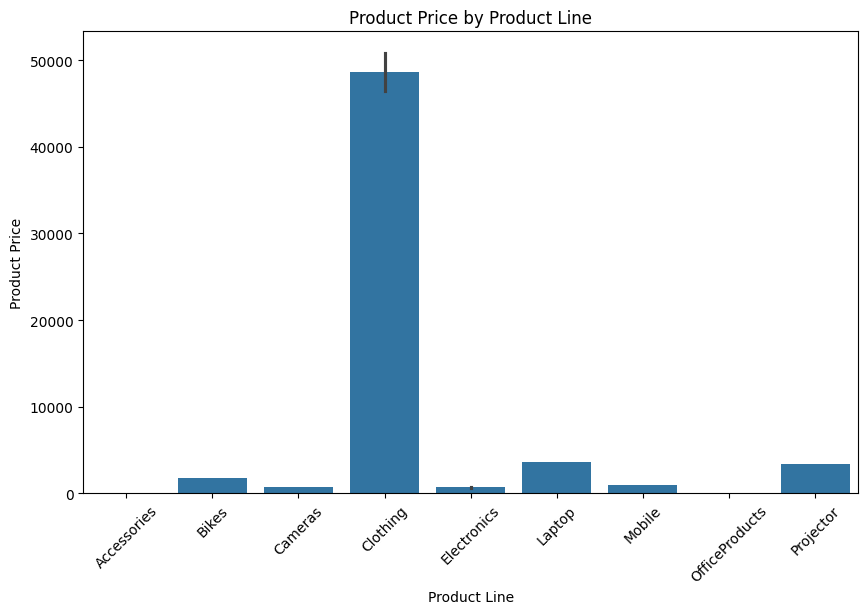

In [59]:
#created bargraph to see product_price, and product_line

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.barplot(x='product_line', y='product_price', data=df)
plt.title('Product Price by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Product Price')
plt.xticks(rotation=45)
plt.show()


In [74]:
#finding the overpriced product
overpriced = df[df['product_price'] > 6000]
print(overpriced[['product_name','product_price']])

                product_name  product_price
36546  Half-Finger Gloves, L       235481.0
36547  Half-Finger Gloves, L       235481.0
36548  Half-Finger Gloves, L       235481.0
36549  Half-Finger Gloves, L       235481.0
36550  Half-Finger Gloves, L       235481.0
...                      ...            ...
37873  Half-Finger Gloves, S       235481.0
37874  Half-Finger Gloves, S       235481.0
37875  Half-Finger Gloves, S       235481.0
37876  Half-Finger Gloves, S       235481.0
37877  Half-Finger Gloves, S       235481.0

[1332 rows x 2 columns]


No gloves should be that expensive....Will be removing those from the data

In [77]:
#checking for outliers in the quantity column
products_over_80 = df[df['quantity'] > 80]
print(products_over_80[['product_name','quantity']])


                                            product_name  quantity
33727                              Water Bottle - 30 oz.     200.0
33822                              Water Bottle - 30 oz.  100000.0
44626                                Projector Black, 44     600.0
45530                                      Gaming Laptop     100.0
45857                               Gaming Laptop Silver     500.0
55308  Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...    2000.0


Unless you're a corporation, there is not reason for one person to be purchasing that many water bottles, or that many gaming laptop

In [84]:
#removing outliers
df_clean = df.copy()

df_clean = df_clean[
    (df_clean['quantity'] <= 80) &
    (df_clean['product_price'] <= 6000) &
    (df_clean['order_date'].dt.year >= 2000) &
    (df_clean['order_date'].dt.year <= 2025)
]
print(df_clean.describe())


           order_id                     order_date      quantity  \
count  54434.000000                          54434  54434.000000   
mean   61605.073373  2023-12-15 18:59:01.933350400      1.490410   
min    45079.000000            2022-01-01 00:00:00      1.000000   
25%    55611.500000            2023-10-05 06:00:00      1.000000   
50%    61821.000000            2024-01-10 00:00:00      1.000000   
75%    68015.000000            2024-04-10 00:00:00      2.000000   
max    74146.000000            2024-06-30 00:00:00     20.000000   
std     7501.842398                            NaN      0.615203   

       product_price  
count   54434.000000  
mean      616.583361  
min         2.290000  
25%         7.950000  
50%       475.600000  
75%       914.620000  
max      3578.270000  
std       817.885974  


## Create Basic Charts

➡️ Assignment Tasks
Your target variable is Total Sales Revenue

Create at least three charts showing revenue broken out by another variable.  

Each visualization should bring some insight into the total sales. You can use any variables for these sample plots.

In [ ]:
#chart 1

In [ ]:
#chart 2

In [ ]:
#chart 3

## Covariance

➡️ Assignment Task
- Create a covariance matrix using all of the applicable independent variables
- In 100 words or less, describe what insight you can derive from the covariance matrix.  What does it tell us about the data?  


In [ ]:
#matrix